In [1]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

C:\Users\mirza\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [2]:
data_dir = 'datasets/archive/kagglecatsanddogs_3367a/PetImages'
IMG_SIZE = (160, 160)   # "high resolution" relative to 32x32 CIFAR, and MobileNetV2's efficient sweet spot
BATCH_SIZE = 32

In [3]:
import time

def safe_remove(path, retries=5, delay=0.5):
    for attempt in range(retries):
        try:
            os.remove(path)
            return True
        except OSError:
            time.sleep(delay)
    print(f"Could not delete after {retries} tries: {path}")
    return False

num_skipped = 0
for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join(data_dir, folder_name)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            with open(fpath, "rb") as fobj:
                is_jfif = b"JFIF" in fobj.peek(10)
        except Exception:
            is_jfif = False
        if not is_jfif:
            num_skipped += 1
            safe_remove(fpath)

print(f"Deleted {num_skipped} corrupt/invalid images")

Deleted 0 corrupt/invalid images


In [4]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

valid_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

class_names = train_dataset.class_names
print("Classes:", class_names)   # label 0 = Cat, label 1 = Dog

Found 23390 files belonging to 2 classes.
Using 18712 files for training.
Found 23390 files belonging to 2 classes.
Using 4678 files for validation.
Classes: ['Cat', 'Dog']


In [5]:
# Overlap I/O (disk read + decode) with compute so the CPU isn't sitting idle
# waiting on the next batch. No .cache() here on purpose -- caching ~25k
# full-res images in RAM can blow past memory on a constrained machine.
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
valid_dataset = valid_dataset.prefetch(buffer_size=AUTOTUNE)

In [6]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

In [7]:
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False   # freeze -- pretrained features already separate cats/dogs very well

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)   # scales to [-1, 1] -- what MobileNetV2 was trained on
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)                                    # only real overfitting risk is this small head -- dropout guards it
outputs = layers.Dense(1, activation='sigmoid')(x)             # binary -> single sigmoid unit, not softmax(2)

model = models.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_160 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │           1,281 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
# Phase 1: train only the head. Base is frozen, so this is fast -- only ~1,300
# trainable params sit on top of the frozen 2.2M-param feature extractor.
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_cat_dog.keras', monitor='val_loss', save_best_only=True)

history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=15,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/15


C:\Users\mirza\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


585/585 ━━━━━━━━━━━━━━━━━━━━ 247s 415ms/step - accuracy: 0.9500 - loss: 0.1263 - val_accuracy: 0.9761 - val_loss: 0.0632
Epoch 2/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 247s 423ms/step - accuracy: 0.9623 - loss: 0.0927 - val_accuracy: 0.9778 - val_loss: 0.0574
Epoch 3/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 245s 419ms/step - accuracy: 0.9672 - loss: 0.0864 - val_accuracy: 0.9791 - val_loss: 0.0553
Epoch 4/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 245s 418ms/step - accuracy: 0.9657 - loss: 0.0867 - val_accuracy: 0.9791 - val_loss: 0.0545
Epoch 5/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 243s 415ms/step - accuracy: 0.9680 - loss: 0.0837 - val_accuracy: 0.9784 - val_loss: 0.0566
Epoch 6/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 243s 415ms/step - accuracy: 0.9689 - loss: 0.0817 - val_accuracy: 0.9799 - val_loss: 0.0552
Epoch 7/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 236s 404ms/step - accuracy: 0.9683 - loss: 0.0863 - val_accuracy: 0.9803 - val_loss: 0.0516
Epoch 8/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 245s 419ms/step - accuracy: 0.9659 - loss: 0.08

In [9]:

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

fine_tune_epochs = 10
history_fine = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=history.epoch[-1] + 1 + fine_tune_epochs,
    initial_epoch=history.epoch[-1] + 1,
    callbacks=[early_stopping, checkpoint]
)

Epoch 13/22
585/585 ━━━━━━━━━━━━━━━━━━━━ 295s 487ms/step - accuracy: 0.9341 - loss: 0.1655 - val_accuracy: 0.9765 - val_loss: 0.0787
Epoch 14/22
585/585 ━━━━━━━━━━━━━━━━━━━━ 296s 506ms/step - accuracy: 0.9551 - loss: 0.1165 - val_accuracy: 0.9810 - val_loss: 0.0580
Epoch 15/22
585/585 ━━━━━━━━━━━━━━━━━━━━ 294s 503ms/step - accuracy: 0.9611 - loss: 0.0991 - val_accuracy: 0.9820 - val_loss: 0.0527
Epoch 16/22
585/585 ━━━━━━━━━━━━━━━━━━━━ 289s 495ms/step - accuracy: 0.9656 - loss: 0.0917 - val_accuracy: 0.9820 - val_loss: 0.0517
Epoch 17/22
585/585 ━━━━━━━━━━━━━━━━━━━━ 312s 534ms/step - accuracy: 0.9663 - loss: 0.0875 - val_accuracy: 0.9810 - val_loss: 0.0525
Epoch 18/22
585/585 ━━━━━━━━━━━━━━━━━━━━ 303s 518ms/step - accuracy: 0.9688 - loss: 0.0791 - val_accuracy: 0.9833 - val_loss: 0.0505
Epoch 19/22
585/585 ━━━━━━━━━━━━━━━━━━━━ 285s 487ms/step - accuracy: 0.9713 - loss: 0.0733 - val_accuracy: 0.9840 - val_loss: 0.0490
Epoch 20/22
585/585 ━━━━━━━━━━━━━━━━━━━━ 281s 480ms/step - accuracy: 

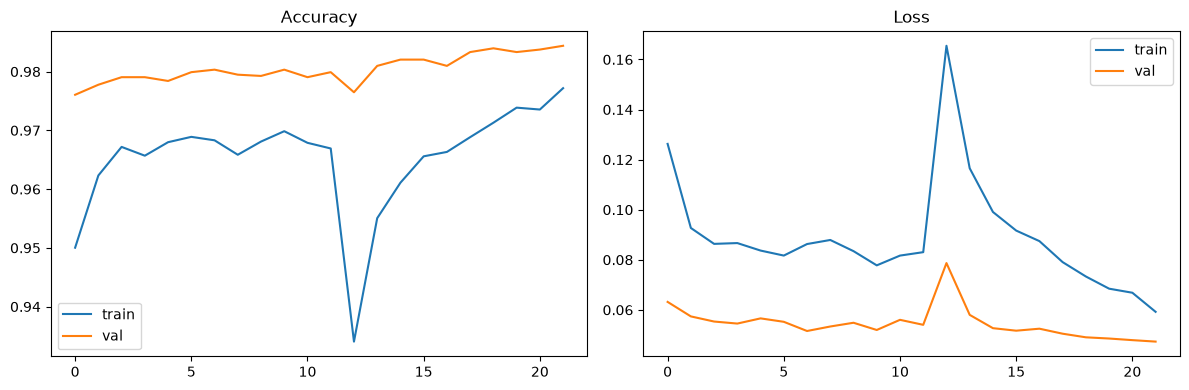

In [12]:
acc = history.history['accuracy'] + history_fine.history.get('accuracy', [])
val_acc = history.history['val_accuracy'] + history_fine.history.get('val_accuracy', [])
loss = history.history['loss'] + history_fine.history.get('loss', [])
val_loss = history.history['val_loss'] + history_fine.history.get('val_loss', [])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(acc, label='train'); axes[0].plot(val_acc, label='val')
axes[0].set_title('Accuracy'); axes[0].legend()
axes[1].plot(loss, label='train'); axes[1].plot(val_loss, label='val')
axes[1].set_title('Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

In [11]:
val_loss, val_acc = model.evaluate(valid_dataset)
print(f"Final validation accuracy: {val_acc:.4f}")

147/147 ━━━━━━━━━━━━━━━━━━━━ 46s 312ms/step - accuracy: 0.9844 - loss: 0.0473
Final validation accuracy: 0.9844
